In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","steel.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [49]:
DMCfiles = np.sort(glob.glob(f'/scratch/user/perry5334/samples/DMC_SNOLAB_HV/CUTE_Cf252calib_source/DMCOutput/CUTE_Cf252_????????_??????.root'))

In [2]:
#DMCfiles = np.sort(glob.glob('/scratch/group/mitchcomp/CDMS/data/nolan/DC3_Production/V2.1.0/Cf252/HV100mm/hits/snolab/HV100mm_DC3Prod-V2.1.0_Cf252-Cryo_10kEvents_Sep9/output/Cf252_snolab_cryo_24240921_0000??.root'))

In [50]:
det = 1 # detector number
df = CDataFrame("G4SimDir/mczip"+str(det), DMCfiles)

In [51]:
data = df.AsNumpy(['EventNum', 'KE', 'Edep', 'KE3', 'PName', 'Process', 'X1', 'X3', 'Y1', 'Y3', 'Z1', 'Z3'])

In [52]:
np.unique(data['PName'])

ndarray(['Ge70', 'Ge72', 'Ge73', 'Ge74', 'Ge76', 'e-', 'gamma'],
        dtype='<U5')

In [53]:
np.unique(data['Process'])

ndarray(['CoupledT', 'compt', 'eBrem', 'eIoni', 'ionIoni', 'msc', 'phot'],
        dtype='<U8')

In [54]:
data['PName'].tolist().count('Ge70')

31

(array([3.71e+03, 1.10e+02, 6.00e+00, 8.00e+00, 1.00e+01, 1.30e+01,
        2.10e+01, 3.00e+01, 1.78e+02, 3.80e+02, 3.00e+02, 1.80e+01,
        9.00e+00, 5.00e+00, 6.00e+00, 3.00e+00, 3.00e+00, 0.00e+00,
        2.00e+00, 2.00e+00, 2.00e+00, 4.00e+00, 1.00e+00, 3.00e+00,
        6.00e+00, 3.00e+00, 6.00e+00, 1.00e+00, 6.00e+00, 1.00e+00,
        2.00e+00, 5.00e+00, 4.00e+00, 8.00e+00, 3.00e+00, 4.00e+00,
        2.00e+00, 1.00e+00, 3.00e+00, 5.00e+00, 4.00e+00, 6.00e+00,
        2.00e+00, 3.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 4.00e+00,
        3.00e+00, 7.00e+00, 0.00e+00, 3.00e+00, 5.00e+00, 3.00e+00,
        3.00e+00, 4.00e+00, 5.00e+00, 1.00e+00, 4.00e+00, 6.00e+00,
        5.00e+00, 6.00e+00, 1.00e+01, 9.00e+00, 4.00e+00, 4.00e+00,
        7.00e+00, 7.00e+00, 2.00e+00, 9.00e+00, 9.00e+00, 1.20e+01,
        1.40e+01, 3.60e+01, 2.10e+01, 4.00e+01, 9.90e+01, 5.70e+01,
        1.17e+02, 3.00e+00, 8.00e+00, 1.00e+01, 1.20e+01, 5.00e+00,
        5.00e+00, 1.50e+01, 3.30e+01, 2.40e+01, 

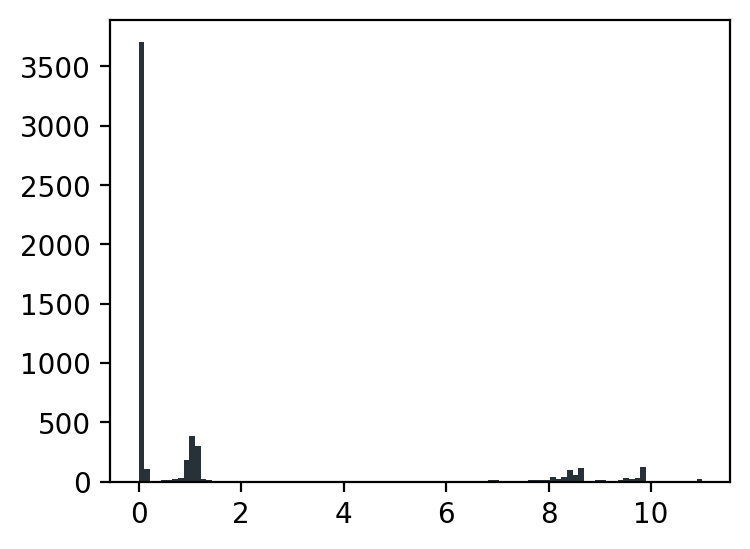

In [55]:
plt.hist(data['KE']*1e-3, bins=np.linspace(0, 11, 101))